# Generation, oversampling, and traceability

This notebook walks through MIMIC generation modes in order: `0` identity, `1` direct, `2` factorised, and `3` joint. Each mode generates minority-class rows for the same two-spiral dataset and shows the trace records used to audit generation.

In [1]:
import sys
from pathlib import Path

from IPython.display import display

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src" / "mimic").exists() else Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
if NOTEBOOK_DIR.exists() and str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from mimic_notebook_utils import class_balance, make_two_spiral_frame, run_generation_mode_demo

RANDOM_STATE = 42
MAJORITY_SAMPLES = 300
MINORITY_SAMPLES = MAJORITY_SAMPLES // 3
CAPACITY = 0.25
CONDITION = {"label": "minority"}

df = make_two_spiral_frame(
    majority_samples=MAJORITY_SAMPLES,
    minority_samples=MINORITY_SAMPLES,
    random_state=RANDOM_STATE,
)
minority_needed = df["label"].value_counts()["majority"] - df["label"].value_counts()["minority"]

display(class_balance(df).style.set_caption("Original class balance"))
display(df.head(8).style.set_caption("Original two-spiral training rows"))


,count
label,
majority,300
minority,100


,x,y,label,id
0,0.261678,0.316023,majority,0
1,0.105739,-0.058441,majority,1
2,0.324877,0.246939,majority,2
3,0.350776,0.122219,majority,3
4,0.005610,0.173272,majority,4
5,0.083987,0.073821,majority,5
6,0.254744,0.180034,majority,6
7,0.199204,0.396551,majority,7


## Mode 0: identity

Identity mode generates in the preprocessed feature space and is a transparent baseline.

,mode,resolved_mode,resolved_level,decode_mode,encoder,decoder,n_generated,trace_rows,cell_trace_rows
0,0,identity,0,direct,IdentityEncoder,IdentityDecoder,200,200,0


,count
label,
majority,300
minority,300


,x,y,label
0,0.219979,-0.628869,minority
1,-2.773873,1.376787,minority
2,-0.935369,-1.896812,minority
3,-2.224457,2.208089,minority
4,-1.913800,-0.601795,minority
5,2.646902,-0.390368,minority
6,-1.518414,0.572935,minority
7,-0.007188,-0.163201,minority


,x,y,label,anchor_index,displacement_from_index,displacement_to_index,lambda,neighbour_mode,condition,decoder
0,0.219979,-0.628869,minority,308,312,316,0.469439,mutual,"{""label"": ""minority""}",IdentityDecoder
1,-2.773873,1.376787,minority,385,384,386,0.297089,mutual,"{""label"": ""minority""}",IdentityDecoder
2,-0.935369,-1.896812,minority,352,355,353,0.630570,mutual,"{""label"": ""minority""}",IdentityDecoder
3,-2.224457,2.208089,minority,378,379,380,0.475193,mutual,"{""label"": ""minority""}",IdentityDecoder
4,-1.913800,-0.601795,minority,350,349,348,0.713382,mutual,"{""label"": ""minority""}",IdentityDecoder
5,2.646902,-0.390368,minority,364,363,361,0.471707,mutual,"{""label"": ""minority""}",IdentityDecoder
6,-1.518414,0.572935,minority,345,344,342,0.527292,mutual,"{""label"": ""minority""}",IdentityDecoder
7,-0.007188,-0.163201,minority,306,303,306,0.565832,mutual,"{""label"": ""minority""}",IdentityDecoder


Text(0.5, 1.02, 'Mode 0: identity oversampling')

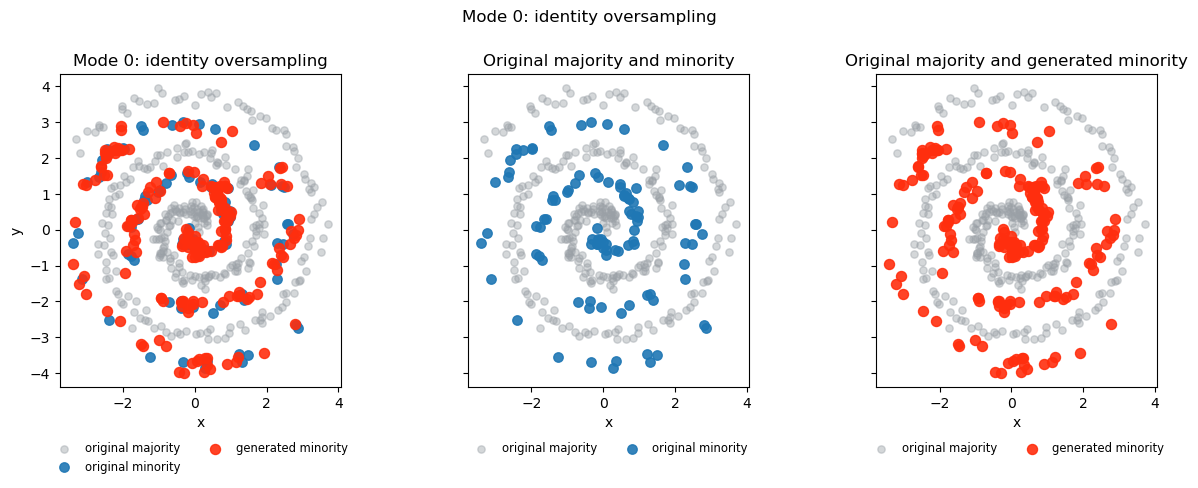

In [2]:
mode0 = run_generation_mode_demo(
    df,
    mode=0,
    capacity=0.0,
    n_samples=minority_needed,
    condition=CONDITION,
    random_state=RANDOM_STATE,
)

display(mode0["summary"].style.set_caption("Mode 0 summary"))
display(mode0["balance"].style.set_caption("Mode 0 class balance after oversampling"))
display(mode0["samples"].head(8).style.set_caption("Mode 0 synthetic minority rows"))
display(mode0["embedding_trace"].head(8).style.set_caption("Mode 0 embedding trace"))
mode0["fig"].suptitle("Mode 0: identity oversampling", y=1.02)


## Mode 1: direct

Direct mode uses learned neural embeddings and deterministic decoding.

,mode,resolved_mode,resolved_level,decode_mode,encoder,decoder,n_generated,trace_rows,cell_trace_rows
0,1,direct,1,direct,ResNetEncoder,NeuralConditionalSampler,200,200,0


,count
label,
majority,300
minority,300


,x,y,label
0,0.032608,0.095046,minority
1,-0.019142,0.268944,minority
2,0.025550,0.152701,minority
3,-0.051574,0.257342,minority
4,0.031069,0.247072,minority
5,0.012537,0.067765,minority
6,0.023482,0.235483,minority
7,0.024888,0.093381,minority


,x,y,label,anchor_index,displacement_from_index,displacement_to_index,lambda,neighbour_mode,condition,decoder
0,0.032608,0.095046,minority,308,314,310,0.469439,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
1,-0.019142,0.268944,minority,385,384,383,0.297089,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
2,0.025550,0.152701,minority,352,354,351,0.630570,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
3,-0.051574,0.257342,minority,378,382,381,0.475193,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
4,0.031069,0.247072,minority,350,349,348,0.713382,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
5,0.012537,0.067765,minority,364,366,367,0.471707,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
6,0.023482,0.235483,minority,345,346,350,0.527292,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
7,0.024888,0.093381,minority,306,302,306,0.565832,mutual,"{""label"": ""minority""}",NeuralConditionalSampler


Text(0.5, 1.02, 'Mode 1: direct oversampling')

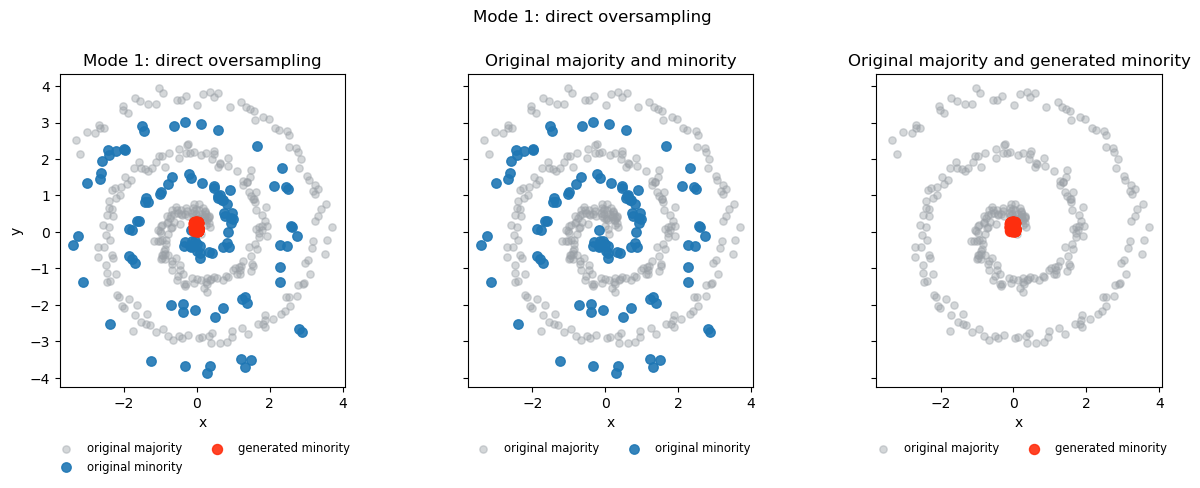

In [3]:
mode1 = run_generation_mode_demo(
    df,
    mode=1,
    capacity=CAPACITY,
    n_samples=minority_needed,
    condition=CONDITION,
    random_state=RANDOM_STATE,
)

display(mode1["summary"].style.set_caption("Mode 1 summary"))
display(mode1["balance"].style.set_caption("Mode 1 class balance after oversampling"))
display(mode1["samples"].head(8).style.set_caption("Mode 1 synthetic minority rows"))
display(mode1["embedding_trace"].head(8).style.set_caption("Mode 1 embedding trace"))
mode1["fig"].suptitle("Mode 1: direct oversampling", y=1.02)


## Mode 2: factorised

Factorised mode adds stochastic feature-wise conditional decoding and exposes per-cell sampling traces.

,mode,resolved_mode,resolved_level,decode_mode,encoder,decoder,n_generated,trace_rows,cell_trace_rows
0,2,factorised,2,factorised,ResNetEncoder,NeuralConditionalSampler,200,1400,1200


,count
label,
majority,300
minority,300


,x,y,label
0,-0.139857,-0.861322,minority
1,-2.955917,1.245107,minority
2,-0.654024,-2.114880,minority
3,-2.322853,1.921085,minority
4,-1.668717,-0.382279,minority
5,3.054318,0.349276,minority
6,-1.660260,-0.210750,minority
7,-0.164048,-0.184819,minority


,x,y,label,anchor_index,displacement_from_index,displacement_to_index,lambda,neighbour_mode,condition,decoder
0,-0.139857,-0.861322,minority,308.000000,314.000000,310.000000,0.469439,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
1,-2.955917,1.245107,minority,385.000000,384.000000,383.000000,0.297089,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
2,-0.654024,-2.114880,minority,352.000000,354.000000,351.000000,0.630570,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
3,-2.322853,1.921085,minority,378.000000,382.000000,381.000000,0.475193,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
4,-1.668717,-0.382279,minority,350.000000,349.000000,348.000000,0.713382,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
5,3.054318,0.349276,minority,364.000000,366.000000,367.000000,0.471707,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
6,-1.660260,-0.210750,minority,345.000000,346.000000,350.000000,0.527292,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
7,-0.164048,-0.184819,minority,306.000000,302.000000,306.000000,0.565832,mutual,"{""label"": ""minority""}",NeuralConditionalSampler


,trace_type,sample_index,condition,decoder,generation_decode_mode,resolved_generation_decode_mode,method,sweep,column,task,sampled_value,conditioning,embedding_slice_start,embedding_slice_stop,member_index,component_index,component_probability,component_mean,component_sigma,sample_log_probability
200,cell,0,"{""label"": ""minority""}",NeuralConditionalSampler,auto,factorised,factorised_conditional,0.000000,x,regression,-0.033210,z_minus_j,0.000000,33.000000,0.000000,1.000000,0.942987,-0.093808,0.070457,1.646948
201,cell,1,"{""label"": ""minority""}",NeuralConditionalSampler,auto,factorised,factorised_conditional,0.000000,x,regression,-2.664495,z_minus_j,0.000000,33.000000,0.000000,1.000000,0.972084,-1.676762,0.157388,0.874028
202,cell,2,"{""label"": ""minority""}",NeuralConditionalSampler,auto,factorised,factorised_conditional,0.000000,x,regression,-0.614002,z_minus_j,0.000000,33.000000,0.000000,1.000000,0.948712,-0.478925,0.072565,1.470691
203,cell,3,"{""label"": ""minority""}",NeuralConditionalSampler,auto,factorised,factorised_conditional,0.000000,x,regression,-2.005927,z_minus_j,0.000000,33.000000,0.000000,1.000000,0.966147,-1.462204,0.144952,0.423221
204,cell,4,"{""label"": ""minority""}",NeuralConditionalSampler,auto,factorised,factorised_conditional,0.000000,x,regression,-1.846145,z_minus_j,0.000000,33.000000,0.000000,1.000000,0.962618,-1.208405,0.116267,1.206631
205,cell,5,"{""label"": ""minority""}",NeuralConditionalSampler,auto,factorised,factorised_conditional,0.000000,x,regression,2.803954,z_minus_j,0.000000,33.000000,0.000000,1.000000,0.929345,1.677671,0.154647,0.912428
206,cell,6,"{""label"": ""minority""}",NeuralConditionalSampler,auto,factorised,factorised_conditional,0.000000,x,regression,-1.588196,z_minus_j,0.000000,33.000000,0.000000,1.000000,0.958499,-1.055249,0.104340,1.305617
207,cell,7,"{""label"": ""minority""}",NeuralConditionalSampler,auto,factorised,factorised_conditional,0.000000,x,regression,0.063368,z_minus_j,0.000000,33.000000,0.000000,1.000000,0.939980,-0.004447,0.074336,1.660910
208,cell,8,"{""label"": ""minority""}",NeuralConditionalSampler,auto,factorised,factorised_conditional,0.000000,x,regression,0.559917,z_minus_j,0.000000,33.000000,0.000000,1.000000,0.937002,0.364395,0.078611,1.305090
209,cell,9,"{""label"": ""minority""}",NeuralConditionalSampler,auto,factorised,factorised_conditional,0.000000,x,regression,0.719167,z_minus_j,0.000000,33.000000,0.000000,1.000000,0.908444,0.512239,0.128150,0.759300


Text(0.5, 1.02, 'Mode 2: factorised oversampling')

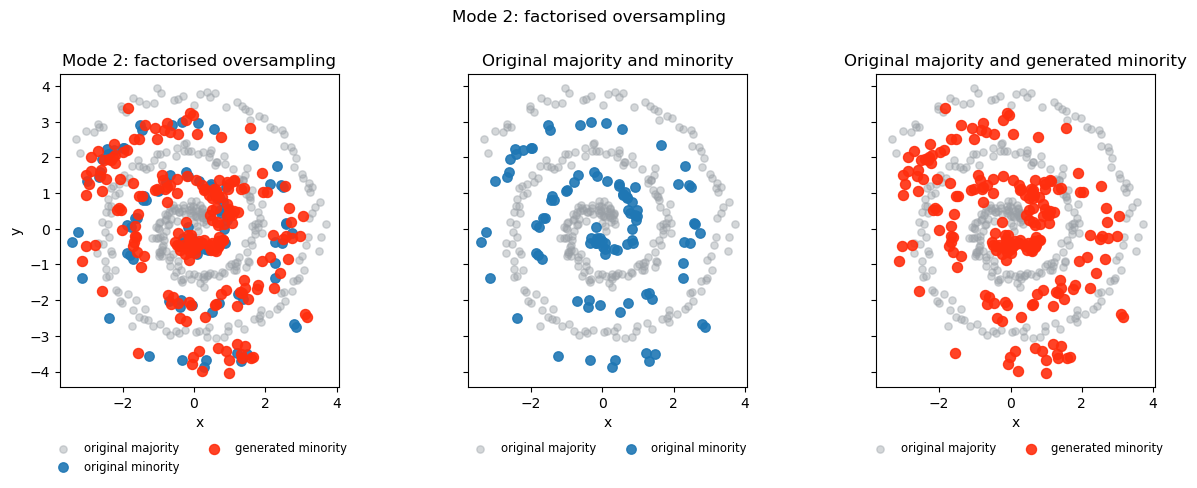

In [4]:
mode2 = run_generation_mode_demo(
    df,
    mode=2,
    capacity=CAPACITY,
    n_samples=minority_needed,
    condition=CONDITION,
    random_state=RANDOM_STATE,
)

display(mode2["summary"].style.set_caption("Mode 2 summary"))
display(mode2["balance"].style.set_caption("Mode 2 class balance after oversampling"))
display(mode2["samples"].head(8).style.set_caption("Mode 2 synthetic minority rows"))
display(mode2["embedding_trace"].head(8).style.set_caption("Mode 2 embedding trace"))
display(mode2["cell_trace"].head(12).style.set_caption("Mode 2 per-cell sampling trace"))
mode2["fig"].suptitle("Mode 2: factorised oversampling", y=1.02)


## Mode 3: joint

Joint mode uses neural conditional evidence and a deterministic joint row decoder.

In [ ]:
mode3 = run_generation_mode_demo(
    df,
    mode=3,
    capacity=CAPACITY,
    n_samples=minority_needed,
    condition=CONDITION,
    random_state=RANDOM_STATE,
)

display(mode3["summary"].style.set_caption("Mode 3 summary"))
display(mode3["balance"].style.set_caption("Mode 3 class balance after oversampling"))
display(mode3["samples"].head(8).style.set_caption("Mode 3 synthetic minority rows"))
display(mode3["embedding_trace"].head(8).style.set_caption("Mode 3 embedding trace"))
mode3["fig"].suptitle("Mode 3: joint oversampling", y=1.02)


KeyboardInterrupt: 

: 